# 0. 環境構築

In [6]:
!uv add -q matplotlib pymc numpy pandas arviz seaborn japanize-matplotlib

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import numpy as np
import pandas as pd
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

%matplotlib inline

g++ not available, if using conda: `conda install gxx`


# 1. 一様分布
- 一様分布とは、ある範囲内のすべての値が等しい確率で生起する確率分布
- ベイズ統計では弱事前分布として使用されることが多い 

Text(0.5, 1.0, 'Uniform Distribution')

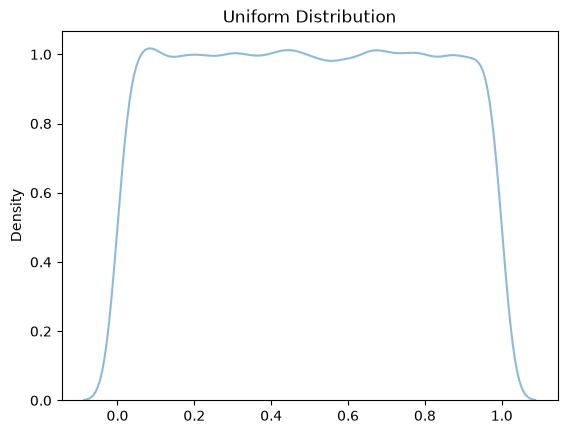

In [18]:
sns.kdeplot(x=pm.Uniform.dist(lower=0, upper=1, size=100000).eval(), alpha=0.5)
plt.title("Uniform Distribution")

# 2. 半正規分布

- 非負値をとる数値の分布。非負のみをとることから、正規分布（`μ`, `σ`）の `σ` に関する事前分布として用いられることが多い。

Text(0.5, 1.0, 'Half-Normal Distributions')

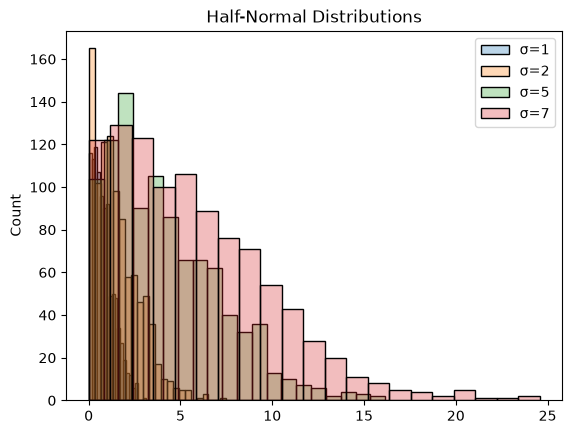

In [35]:
sigmas = [1, 2, 5, 7]

for sigma in sigmas:
    sns.histplot(x=pm.HalfNormal.dist(mu=0, sigma=sigma, size=1000).eval(), label=f"σ={sigma}", fill=True, alpha=0.3)
plt.legend()
plt.title("Half-Normal Distributions")

# 3. ポワソン分布
https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Poisson.html
- ポワソン分布は離散分布となり、めったに起きないカウントデータの生起確率を示す。
- ポワソン分布は **平均 = 分散** となる特徴があり、分散 > 平均（過分散） となるようなケースでは負の二項分布に拡張する必要がある。
- 単位時間（または単位空間）あたりに平均して $\lambda$ 回発生する事象が、その期間内にちょうど $k$ 回発生する確率は以下の式で表されます。
- ポワソン回帰では確率分布に使用され、 $\lambda$ のリンク関数としては **対数リンク関数** が使用されることが多い。（※ $\lambda$ は非負かつ値が小さいことが多いため）



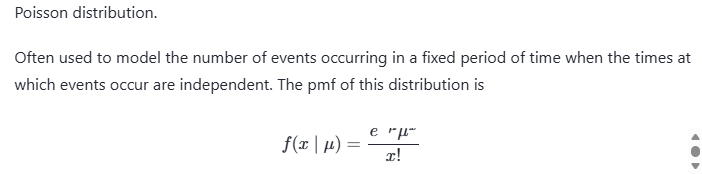

Text(0.5, 1.0, 'Poisson Distributions')

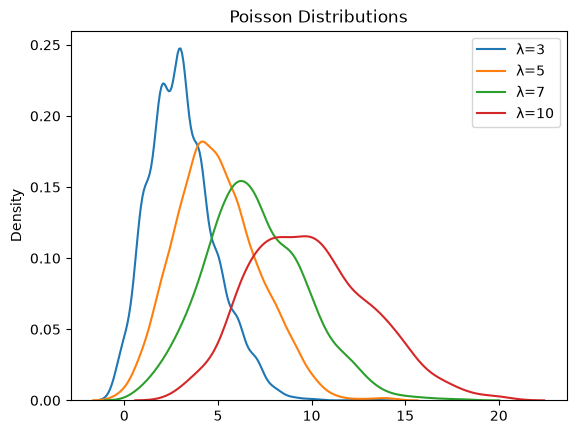

In [61]:
lamdas = [3, 5, 7, 10]

[sns.kdeplot(x=pm.Poisson.dist(mu=lamda, size=1000).eval(), label=f"λ={lamda}") for lamda in lamdas]
plt.legend()
plt.title("Poisson Distributions")

# 4. 二項分布
https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Binomial.html
- 成功確率：$p$ , 試行回数：$n$ に対して、X回成功が出る確率

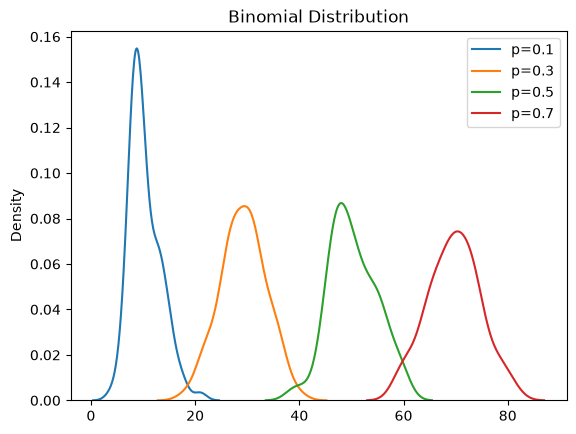

In [60]:
pars = [0.1, 0.3, 0.5, 0.7]

[sns.kdeplot(x=pm.Binomial.dist(n=100, p=p, size=100).eval(), label=f"p={p}") for p in pars]
plt.title("Binomial Distribution")
plt.legend()